In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Everything works!")

Everything works!


In [2]:
import os

print(os.listdir())

['.config', 'marketing aanalysis.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("marketing aanalysis.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,58138.0,0,0,58,635,88,546,172,88,88
1,46344.0,1,1,38,11,1,6,2,1,6
2,71613.0,0,0,26,426,49,127,111,21,42
3,26646.0,1,0,26,11,4,20,10,3,5
4,58293.0,1,0,94,173,43,118,46,27,15


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Income            2205 non-null   float64
 1   Kidhome           2205 non-null   int64  
 2   Teenhome          2205 non-null   int64  
 3   Recency           2205 non-null   int64  
 4   MntWines          2205 non-null   int64  
 5   MntFruits         2205 non-null   int64  
 6   MntMeatProducts   2205 non-null   int64  
 7   MntFishProducts   2205 non-null   int64  
 8   MntSweetProducts  2205 non-null   int64  
 9   MntGoldProds      2205 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 172.4 KB


,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [5]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df[['Income','Total_Spending']].head()

,Income,Total_Spending
0,58138.0,1617
1,46344.0,27
2,71613.0,776
3,26646.0,53
4,58293.0,422


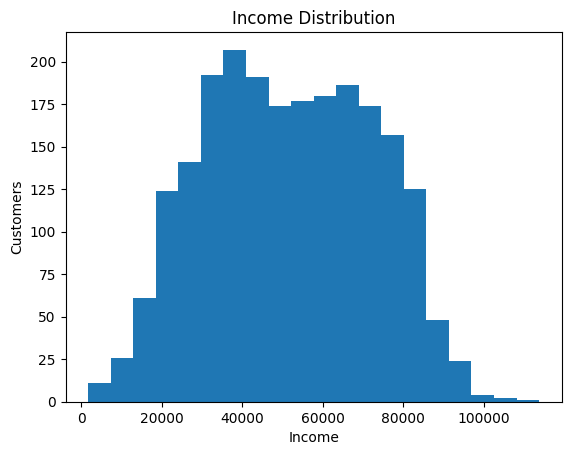

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['Income'], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Customers")
plt.show()

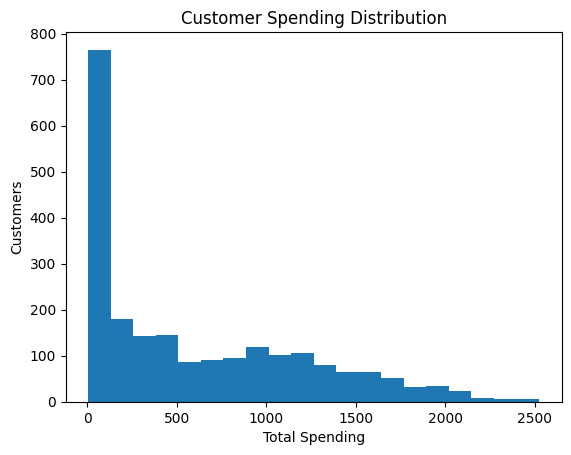

In [7]:
plt.hist(df['Total_Spending'], bins=20)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Customers")
plt.show()

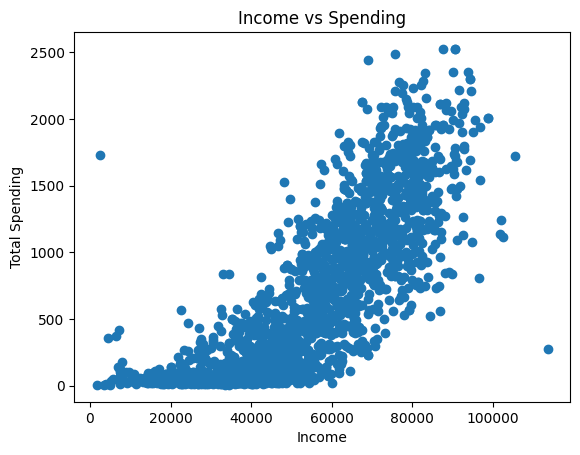

In [8]:
plt.scatter(df['Income'], df['Total_Spending'])
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Income vs Spending")
plt.show()

In [9]:
from sklearn.cluster import KMeans

In [11]:
X = df[['Income','Total_Spending']]

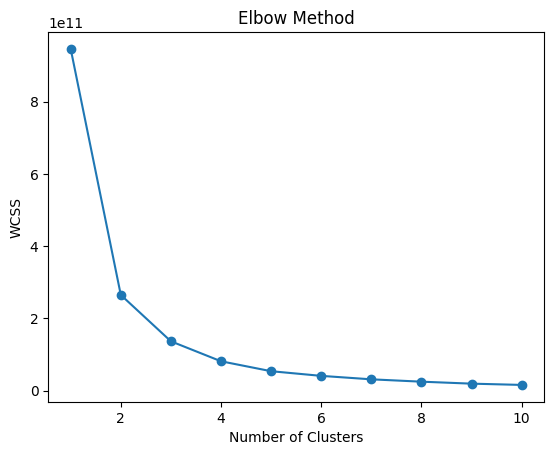

In [12]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,1617,2
1,46344.0,1,1,38,11,1,6,2,1,6,27,3
2,71613.0,0,0,26,426,49,127,111,21,42,776,0
3,26646.0,1,0,26,11,4,20,10,3,5,53,1
4,58293.0,1,0,94,173,43,118,46,27,15,422,2


In [15]:
df['Cluster'].value_counts()

,count
Cluster,
3,665
2,622
0,463
1,455


In [16]:
df.groupby('Cluster')[['Income','Total_Spending']].mean()

,Income,Total_Spending
Cluster,,
0,80048.000000,1405.872570
1,23279.883516,73.465934
2,61610.898714,816.752412
3,41879.953383,219.061654


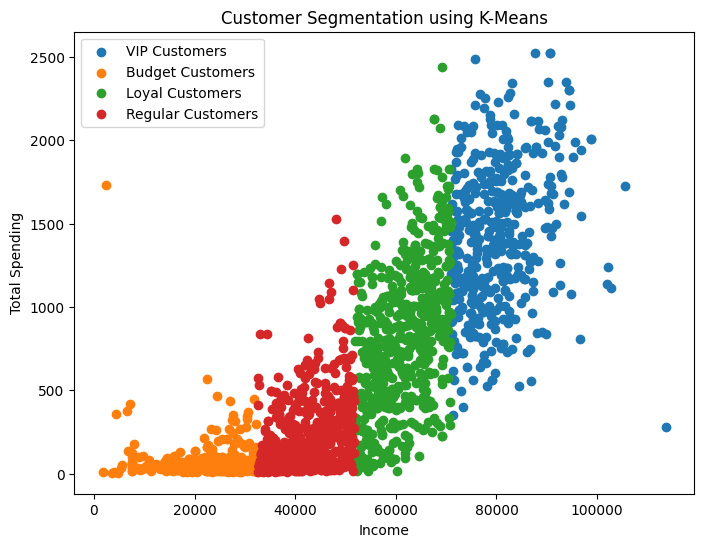

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df[df['Cluster']==0]['Income'],
            df[df['Cluster']==0]['Total_Spending'],
            label='VIP Customers')

plt.scatter(df[df['Cluster']==1]['Income'],
            df[df['Cluster']==1]['Total_Spending'],
            label='Budget Customers')

plt.scatter(df[df['Cluster']==2]['Income'],
            df[df['Cluster']==2]['Total_Spending'],
            label='Loyal Customers')

plt.scatter(df[df['Cluster']==3]['Income'],
            df[df['Cluster']==3]['Total_Spending'],
            label='Regular Customers')

plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

Insights
1. VIP Customers (Cluster 0)
Average Income: ₹80,048
Average Spending: ₹1,405.87
Total Customers: 463

Insight:
These customers have the highest income and spending levels. They contribute significantly to revenue and represent the most valuable customer segment.

2. Loyal Customers (Cluster 2)
Average Income: ₹61,611
Average Spending: ₹816.75
Total Customers: 622

Insight:
This is the largest customer segment. They have good purchasing power and regularly spend on products, making them important for sustained business growth.

3. Regular Customers (Cluster 3)
Average Income: ₹41,880
Average Spending: ₹219.06
Total Customers: 665

Insight:
These customers make occasional purchases and represent average spending behavior. With targeted promotions, they can potentially move into higher-value segments.

4. Budget Customers (Cluster 1)
Average Income: ₹23,280
Average Spending: ₹73.47
Total Customers: 455

Insight:
These customers have lower purchasing power and spending levels. Price-sensitive offers and discounts may encourage increased engagement.

Business Recommendations
1. Reward VIP Customers:
Offer exclusive memberships.
Provide early access to new products.
Introduce premium loyalty programs.
2. Retain Loyal Customers:
Provide personalized recommendations.
Offer reward points and cashback incentives.
Encourage repeat purchases through targeted campaigns.
3. Upsell Regular Customers:
Use bundle offers and seasonal promotions.
Recommend complementary products.
Create targeted marketing campaigns to increase spending.
4. Engage Budget Customers:
Offer discounts and value-based packages.
Promote affordable products.
Use special offers to encourage more frequent purchases.
5. Data-Driven Marketing:
Tailor marketing strategies based on customer segments.
Allocate resources differently for each segment.
Continuously monitor customer movement between clusters.

Conclusion

The Customer Segmentation Analysis successfully grouped customers into four distinct segments using K-Means Clustering. The analysis identified VIP Customers, Loyal Customers, Regular Customers, and Budget Customers based on income and spending behavior. These insights can help businesses implement targeted marketing strategies, improve customer retention, and maximize revenue growth.
